# BII script

In [3]:
%load_ext dotenv
%dotenv .env

In [4]:
import cog_worker
from cog_worker import Worker, Manager
import rasterio as rio
from rasterio.plot import show, show_hist
import numpy as np
import pandas as pd
import pystac_client
import matplotlib.pyplot as plt
import mahotas
from scipy import ndimage

In [5]:
STAC_API_URL = 'http://io-stac-internal.impactobservatory.com/'

ABUNDANCE_COEFFICIENTS = {
    'Intercept': 3.70170553703471,
    "ln_distRoads":-0.00981977902849513,
    "ln_pD2006_1000m":-0.096305338569171,
    "lcCrops_100m":-0.072689104315292,
    "lcBuiltArea_1000m":0.254091185638773,
    "lcBuiltArea_100m":-0.176460730121838,
    "forestLoss2006_100m":-0.155530295244675
}
ABUNDANCE_TRANSFORM = 'log'


COMMUNITY_SIMILARITY_COEFFICIENTS = {
    'Intercept': 0.218130679408732,
    "ln_distRoads":0.0181332392937601,
    "ln_accessibility":0.137135301580816,
    "ln_pD2006_1000m":0.252785443092897,
    "ln_nL2012_1000m":-0.313937017511882,
    "lcCrops_1000m":-0.935394995786293,
    "lcCrops_100m":-0.248198099726017,
    "lcBuiltArea_1000m":-0.745895005503182,
    "forestManagement_100m":-0.769972275297042,
    "forestLoss2006_100m":0.339447252726624,
}
COMMUNITY_SIMILARITY_TRANSFORM = 'logit'

INVERSE_TRANSFORMS = {
    'sqrt': lambda x: x**2,
    'logit': lambda x: 1/(1+np.exp(-x)),
    'log': lambda x: np.exp(x),
}

STATIC_ASSETS = {
    'forestManagement': {
        'collections':['io-vizz-dynamic-science-FML-v3-2']
    },
    'accessibility': {
        'collections':['io-vizz-dynamic-science-city-travel-times']
    },
    'roads': {
        'collections':['io-vizz-dynamic-science-osm-roads-100m-20210204']
    },
    'forestLoss': {
        'collections':['unbl-global-forest-watch'],
        'url':'https://io-stac-navigator.impactobservatory.com',
        'assets':['lossyear']
    }
}
ANNUAL_ASSETS = {
    'landcover': {
        'collections':["io-lulc-model-001-v02-composite-v01-supercell-v02-clip-v01"]
    },
    'population': {
        'collections':['io-vizz-dynamic-science-worldpop']
    },
    'nightlights': {
        'collections':['io-vizz-dynamic-science-VNL-v2']
    },
}

START_YEAR = 2017
END_YEAR = 2020

DEG2METERS = 111319.49079327357


In [6]:
def stac_search(url, assets=None, **kwargs):
    client = pystac_client.Client.open(url, ignore_conformance=True)
    asset_filters = assets or []
    try:
        items = client.search(**kwargs).get_items()
        asset_hrefs = [
            asset.href
            for item in items
            for k, asset in item.assets.items()
            if k in asset_filters or not asset_filters
        ]
    except Exception as e:
        if e.args[0] == "{'detail': 'No items found'}": 
            return []
        raise e
    
    return asset_hrefs


def read_stac(worker, **kwargs):
    bounds = worker.lnglat_bounds()
    if not np.isfinite(bounds).all():
        return worker.read([])

    stac_args = {
        'url': STAC_API_URL,
        'bbox': bounds,
        'limit': 10000,
    }
    stac_args.update(kwargs)
    assets = stac_search(**stac_args)
    assets = [f'/vsiaz/{a[5:]}' if a.startswith('az://') else a for a in assets]
    
    with rio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR',
        VSI_CACHE='FALSE',
        VSIL_CACHE_SIZE='0',
    ):
        return worker.read(assets)




In [7]:
'''
Forest Management
    11: 0,  # Forest without any signs of human impact
    20: 0,  # Forest with signs of human impact, including clear cuts, logging, built-up roads 
    31: 1,  # Replanted forest, forest with rotation period longer than 20 years
    32: 1,  # Woody plantations, rotation period of maximum 15 years 
    40: 1,  # Oil palm plantations
    53: 1,  # Agroforestry, including fruit tree plantations, tree shelterbelts, individual trees on pastures
'''


'\nForest Management\n    11: 0,  # Forest without any signs of human impact\n    20: 0,  # Forest with signs of human impact, including clear cuts, logging, built-up roads \n    31: 1,  # Replanted forest, forest with rotation period longer than 20 years\n    32: 1,  # Woody plantations, rotation period of maximum 15 years \n    40: 1,  # Oil palm plantations\n    53: 1,  # Agroforestry, including fruit tree plantations, tree shelterbelts, individual trees on pastures\n'

### Main projection function

In [15]:

def get_static_assets(worker):
    return {k:read_stac(worker, **v) 
        for k,v in STATIC_ASSETS.items()}

def get_annual_assets(worker, year=START_YEAR):
    return {k:read_stac(worker, datetime=f'{year}-01-01/{year}-12-31', **v)
        for k,v in ANNUAL_ASSETS.items()}
        
def nominal_scale(worker):
    if worker.proj.crs.is_geographic:
        return worker.scale * DEG2METERS
    return worker.scale

def convolve(arr, radius, scale=1, dtype=float):
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    kernel_size = round(radius / scale)
    return ndimage.uniform_filter(arr.astype(dtype), kernel_size)[np.newaxis]

def fast_distance_transform(arr):
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    return mahotas.distance(np.logical_not(arr))[np.newaxis]
    
    
def calc_bii(worker, layers=None, year=START_YEAR, return_all=False):
    if layers is None:
        layers = (
            get_static_assets(worker)
            | get_annual_assets(worker)
        )
    
    scale = nominal_scale(worker)

    forestManagement = ((layers['forestManagement']>30) & (layers['forestManagement']<55)).data
    forestLoss = (layers['forestLoss'] <= year-2000) & (layers['forestLoss'] > 0).data
    distRoads = np.sqrt(fast_distance_transform(layers['roads'])) * scale
    distRoads = np.clip(distRoads, 0, 10000)
    ln_distRoads = np.log(distRoads+1)
    accessibility = np.clip(layers['accessibility'].data, 0, 1440)
    ln_accessibility = np.log(accessibility+1)
    ln_nightlights = np.log(layers['nightlights']+1).data
    population = np.nan_to_num(np.ma.filled(layers['population'], 0), 0)
    ln_population = np.log(population+1)
    crops = layers['landcover'].data == 5
    builtArea = layers['landcover'].data == 7
    nodata = ~(layers['landcover'].data>1)

    predictors = {
        'ln_distRoads': ln_distRoads,
        'ln_accessibility': ln_accessibility,
        'ln_nL2012_1000m': convolve(ln_nightlights, 2000, scale),
        'ln_pD2006_1000m': convolve(ln_population, 2000, scale),
        'forestManagement_100m': convolve(forestManagement, 200, scale),
        'lcCrops_1000m': convolve(crops, 2000, scale),
        'lcCrops_100m': convolve(crops, 200, scale),
        'lcBuiltArea_1000m': convolve(builtArea, 2000, scale),
        'lcBuiltArea_100m': convolve(builtArea, 200, scale),
        'forestLoss2006_100m': convolve(forestLoss, 200, scale),
        'Intercept': 1
    }

    abundance_max = INVERSE_TRANSFORMS[ABUNDANCE_TRANSFORM](
        ABUNDANCE_COEFFICIENTS['Intercept']
        + ABUNDANCE_COEFFICIENTS.get('ln_accessibility', 0) * np.log(1440)
        + ABUNDANCE_COEFFICIENTS.get('ln_distRoads', 0) * np.log(10000)
    )
    abundance = np.sum([predictors[k]*v for k,v in ABUNDANCE_COEFFICIENTS.items()])
    abundance = INVERSE_TRANSFORMS[ABUNDANCE_TRANSFORM](abundance) / abundance_max
    
    community_similarity_max = INVERSE_TRANSFORMS[COMMUNITY_SIMILARITY_TRANSFORM](
        COMMUNITY_SIMILARITY_COEFFICIENTS['Intercept']
        + COMMUNITY_SIMILARITY_COEFFICIENTS.get('ln_accessibility', 0) * np.log(1440)
        + COMMUNITY_SIMILARITY_COEFFICIENTS.get('ln_distRoads', 0) * np.log(10000)
    )
    community_similarity = np.sum([predictors[k]*v for k,v in COMMUNITY_SIMILARITY_COEFFICIENTS.items()])
    community_similarity = INVERSE_TRANSFORMS[COMMUNITY_SIMILARITY_TRANSFORM](community_similarity) / community_similarity_max

    bii = abundance * community_similarity
    results = {
        'abundance': np.ma.MaskedArray(abundance, mask=nodata),
        'community_similarity': np.ma.MaskedArray(community_similarity, mask=nodata),
        'bii': np.ma.MaskedArray(bii, mask=nodata),
    }

    if return_all:
        return layers | predictors | results
    return results


def compute_all(worker):
    static_assets = get_static_assets(worker)

    all_results = {}

    for year in range(START_YEAR, END_YEAR+1):
        assets = static_assets | get_annual_assets(worker, year)
        for k,v in calc_bii(worker, assets, year).items():
            all_results[f'{k}_{year}'] = v

    return all_results

In [16]:
scale = 100
scale_deg = scale/DEG2METERS
buffer = round(10000/scale)

manager = cog_worker.Manager(
    #bounds=(95, -10, 125, 10),
    #bounds=(108, -2, 112, 2),
    bounds=(-86, 9, -84, 11),
    scale=scale_deg,
    proj='EPSG:4326',
    buffer=buffer
)


In [18]:
worker = cog_worker.Worker(
    bounds=(-86, 9, -84, 11),
    scale=scale_deg*10,
    proj='EPSG:4326',
    buffer=buffer
)

/usr/local/homebrew/lib/python3.9/site-packages/numpy/core/fromnumeric.py:87: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


forestManagement


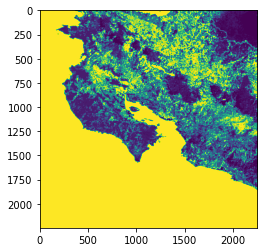

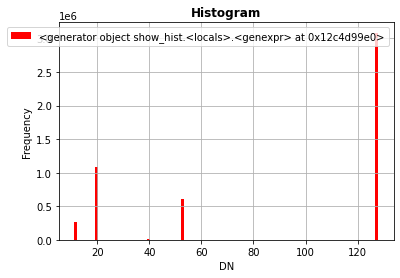

accessibility


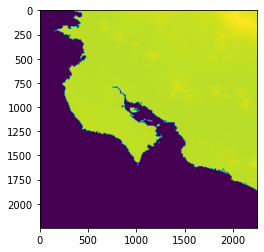

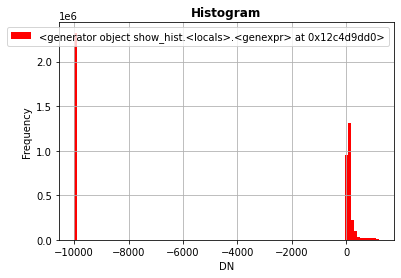

roads


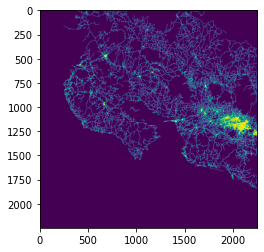

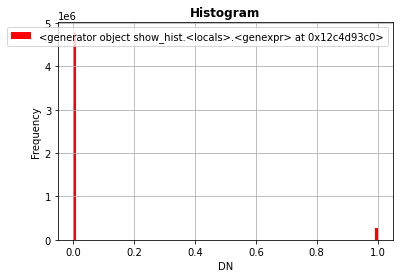

forestLoss


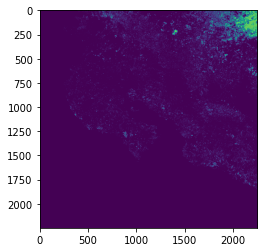

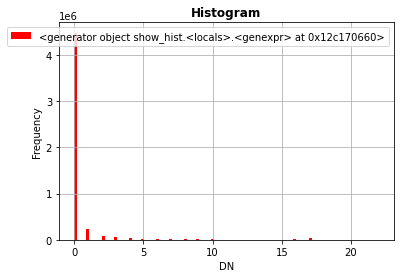

landcover


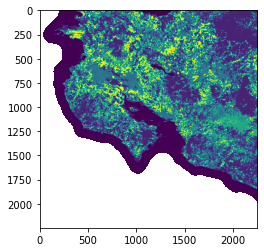

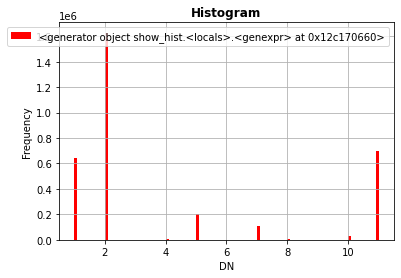

population


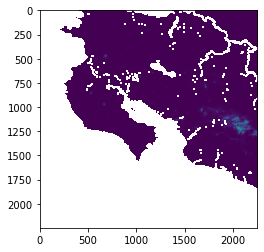

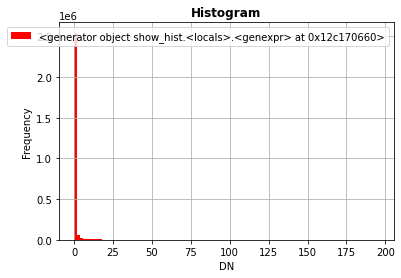

nightlights


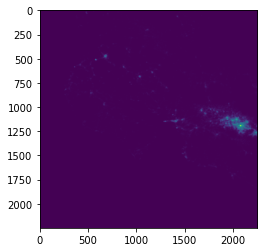

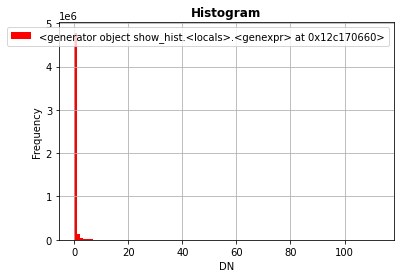

ln_distRoads


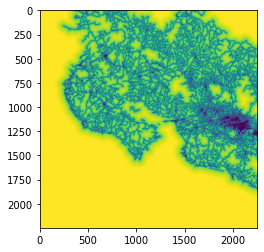

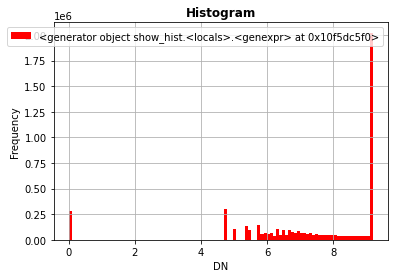

ln_accessibility


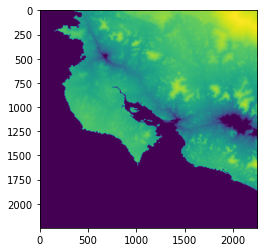

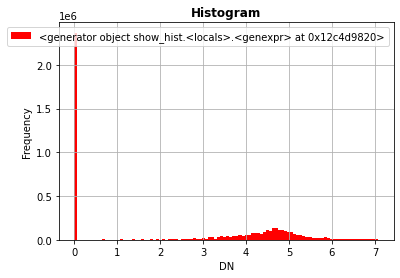

ln_nL2012_1000m


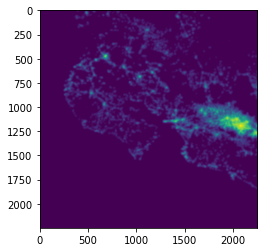

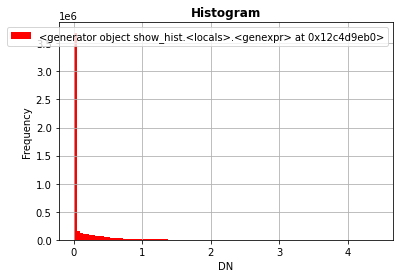

ln_pD2006_1000m


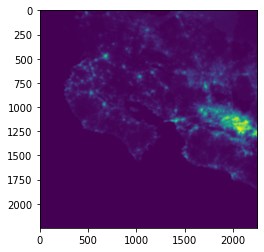

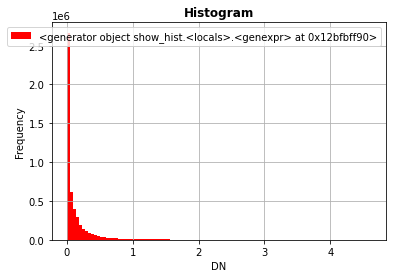

forestManagement_100m


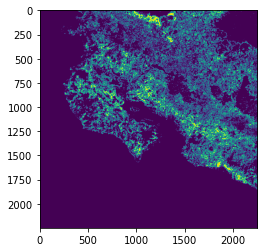

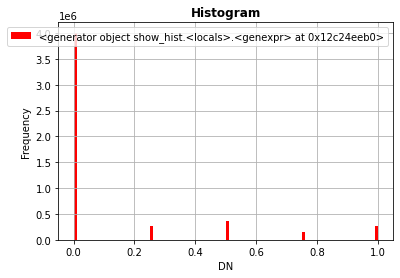

lcCrops_1000m


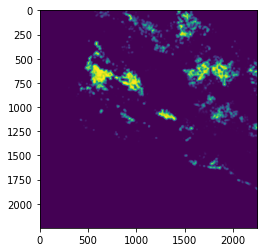

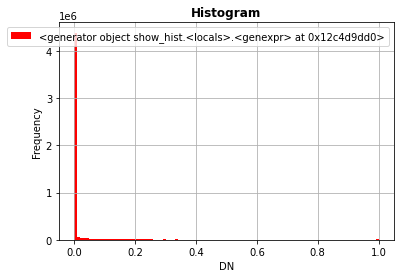

lcCrops_100m


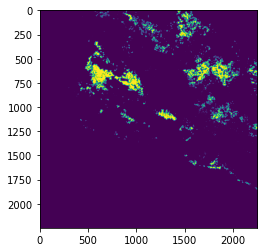

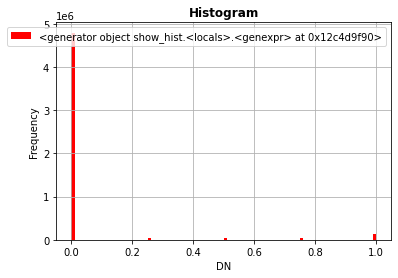

lcBuiltArea_1000m


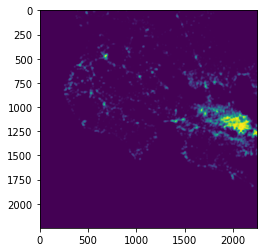

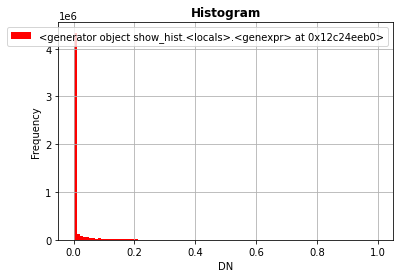

lcBuiltArea_100m


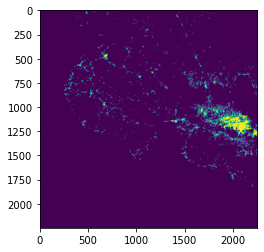

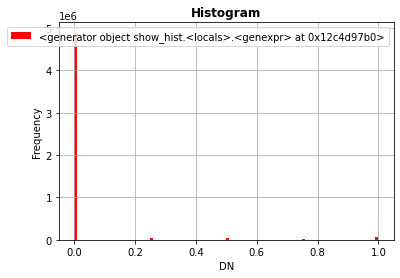

forestLoss2006_100m


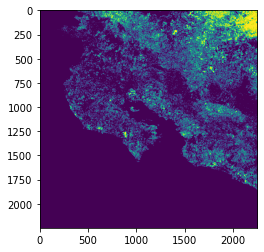

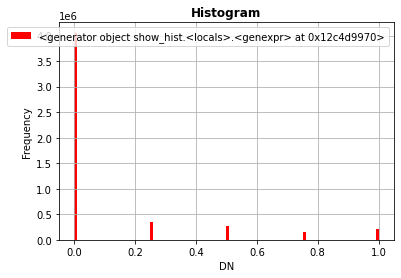

Intercept
Invalid shape () for image data
abundance


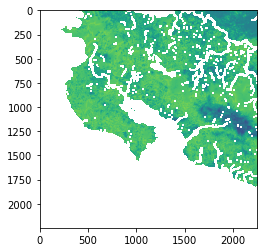

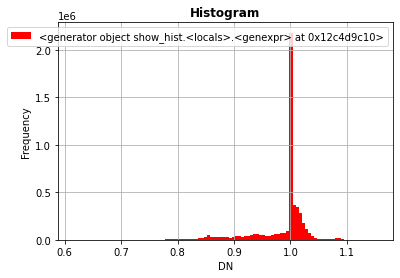

community_similarity


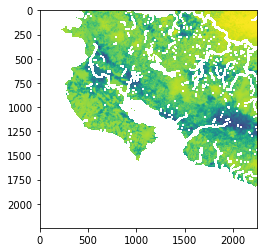

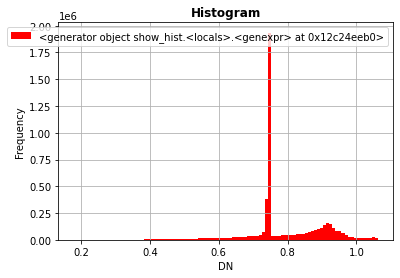

bii


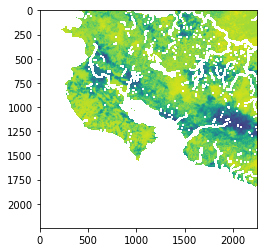

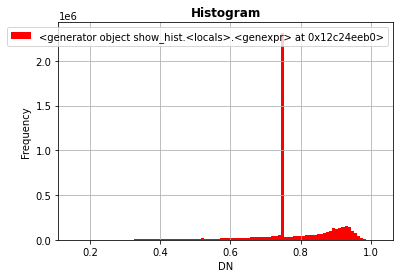

In [19]:
lyrs, _ = manager.preview(calc_bii, [], {'return_all':True}, max_size=2048)
for k,v in lyrs.items():
    print(k)
    try:
        show(v)
        show_hist(v, bins=100)
    except Exception as e:
        print(e)
        pass

In [20]:
lyrs, _ = manager.preview(compute_all, max_size=2048)
for k,v in lyrs.items():
    print(k)
    try:
        show(v)
        show_hist(v, bins=100)
    except Exception as e:
        print(e)
        pass

KeyboardInterrupt: 

<AxesSubplot:>

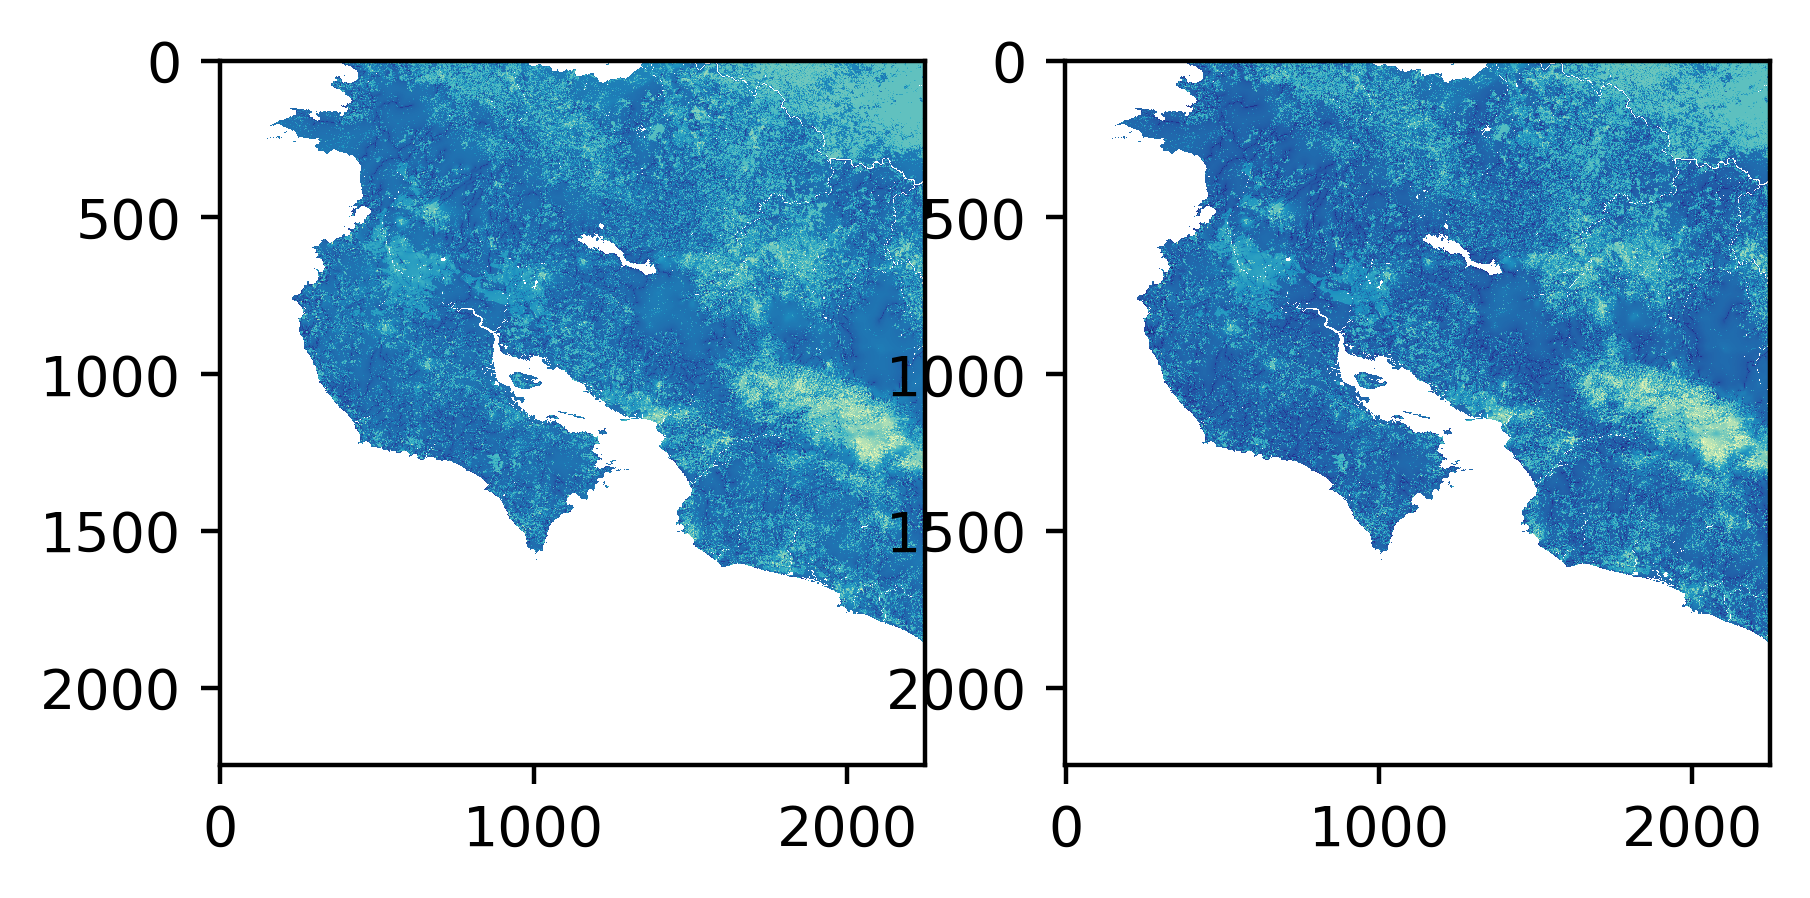

In [ ]:
arr = lyrs['bii_2020']
fig, axs = plt.subplots(1, 2, figsize=(5,11), dpi=400)
show(arr, ax=axs[0], interpolation='none', cmap='YlGnBu')
arr = lyrs['bii_2017']
show(arr, ax=axs[1], interpolation='none', cmap='YlGnBu')